In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from scipy.stats import zscore
import skimage as ski
from pydicom import dcmread
import cv2 as cv

import os 
import shutil
import glob
import re


In [5]:
SSD_path = '../../../../../Volumes/SSD_01/'

mrkr_data_path ='../../../../../Volumes/HDD_02/datasets/emory_mrkr/'
mrkr_data_path = os.path.abspath(mrkr_data_path)

In [4]:
image_df = pd.read_csv(os.path.join(mrkr_data_path,'tables','MRKR_image_metadata.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/HDD_02/datasets/emory_mrkr/tables/MRKR_image_metadata.csv'

In [16]:
image_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,inverted,arthroplasty,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,0,0,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,0,0,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...
2,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.13086143241040152779...,1774.0,1045.0,R,I,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
3,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.13222315862241217925...,1774.0,1045.0,R,F,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
4,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.15405157314397326116...,1774.0,1044.0,L,F,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...


In [17]:
lateral_view_df = image_df[image_df.view_position == 'L']
lateral_view_df.reset_index(inplace=True, drop=True)

In [18]:
lateral_view_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,inverted,arthroplasty,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,0,0,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,0,0,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...
2,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.25097243441976964330...,1775.0,1059.0,R,L,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
3,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.73980548070501957600...,1771.0,1058.0,L,L,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
4,10003180,1.2.845.113979.3.64.1.55016411.20170539.1,1.2.846.113564.1632467445.20170530081259855397,1.2.826.0.1.3680043.8.498.12678074990125916447...,2517.0,1985.0,R,L,0.0,1.0,0,R,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2017-11-09,67,10003180/1.2.845.113979.3.64.1.55016411.201705...


<Axes: xlabel='laterality'>

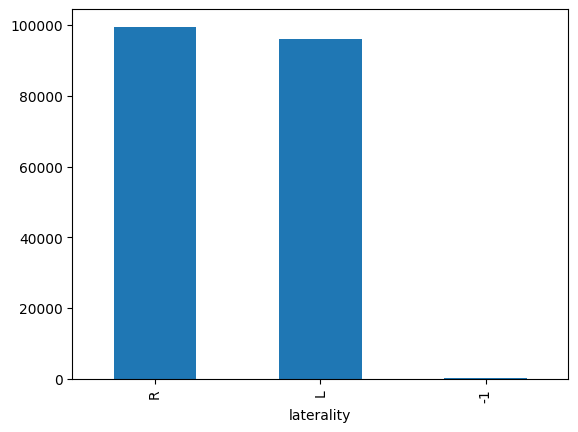

In [19]:
lateral_view_df.laterality.value_counts().plot(kind='bar')

<Axes: xlabel='arthroplasty'>

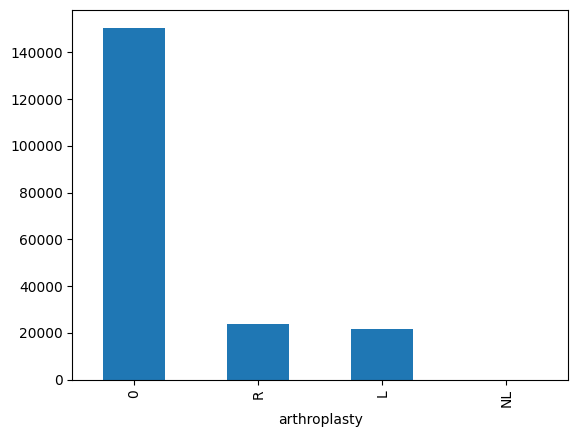

In [20]:
lateral_view_df.arthroplasty.value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

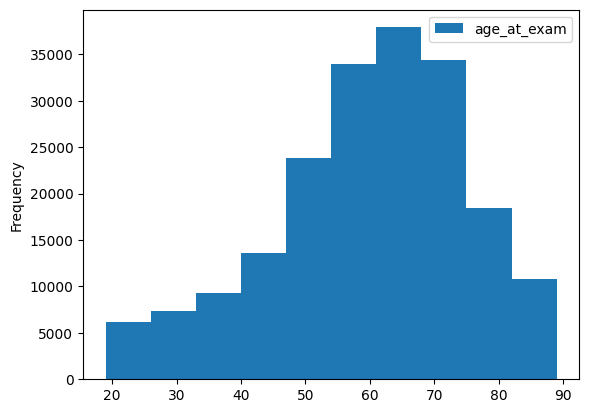

In [21]:
lateral_view_df.plot(kind='hist',y='age_at_exam')

In [52]:
image_path_test = os.path.join(mrkr_data_path,
             'images',
             lateral_view_df.head().iloc[0].dicom_path)


In [53]:
image_path_test

'/Volumes/HDD_02/datasets/emory_mrkr/images/10001182/1.2.849.113972.3.57.1.62631357.20201023.1122916/1.2.840.113570.163246170217.20201019125748437223/1.2.826.0.1.3680043.8.498.40281381358579896373342050665884572628.dcm'

In [24]:
test_img = dcmread(image_path_test)

In [25]:
import time

start = time.time()
ds = dcmread(image_path_test)
print("Read header:", time.time() - start)

start = time.time()
_ = ds.pixel_array
print("Decode pixels:", time.time() - start)

Read header: 0.0024368762969970703
Decode pixels: 0.12138700485229492


In [54]:
image_path_test1 = os.path.join(mrkr_data_path,
             'images',
             lateral_view_df.head().iloc[1].dicom_path)

start = time.time()
ds = dcmread(image_path_test1)
print("Read header:", time.time() - start)

start = time.time()
_ = ds.pixel_array
print("Decode pixels:", time.time() - start)


Read header: 0.5884668827056885
Decode pixels: 0.1385793685913086


In [27]:
SSD_xray_path = os.path.join(SSD_path,'Projects','knee_xray_landmarks')

In [28]:
# shutil.copy(image_path_test1, SSD_xray_path)

In [29]:
start = time.time()
ds = dcmread(image_path_test)
print("Read header:", time.time() - start)

start = time.time()
_ = ds.pixel_array
print("Decode pixels:", time.time() - start)

Read header: 0.5203940868377686
Decode pixels: 0.13870596885681152


In [30]:
image_path_test1_SSD = os.path.join(SSD_xray_path,
                                image_path_test1.split('/')[-1])

start = time.time()
ds = dcmread(image_path_test1_SSD)
print("Read header:", time.time() - start)

start = time.time()
_ = ds.pixel_array
print("Decode pixels:", time.time() - start)


FileNotFoundError: [Errno 2] No such file or directory: '../../../../../Volumes/SSD_01/Projects/knee_xray_landmarks/1.2.826.0.1.3680043.8.498.73756677603175613024520577973142638483.dcm'

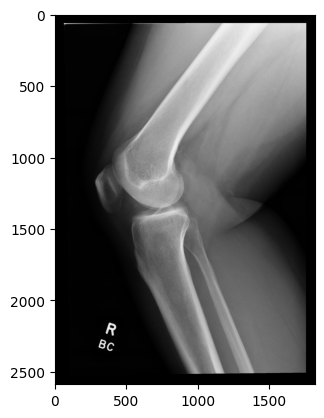

In [55]:
test_img_arr1 =ds.pixel_array.astype(np.float32)
plt.imshow(test_img_arr1, cmap='gray')


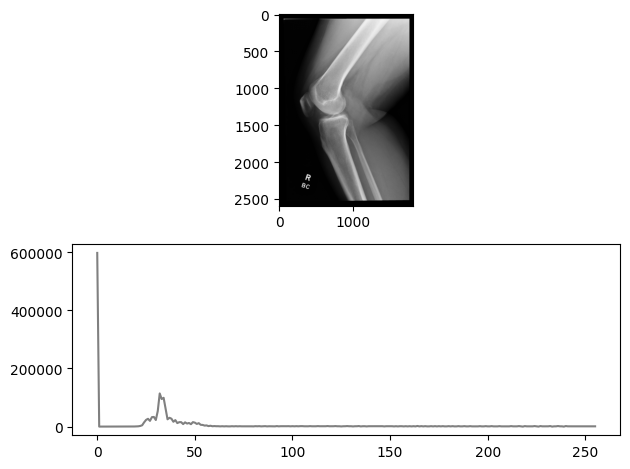

In [56]:
hist_full = cv.calcHist([test_img_arr1], [0], None, [256], [0,256])


plt.subplot(211), plt.imshow(test_img_arr1, 'gray')
plt.subplot(212), plt.plot(hist_full,'gray')
plt.tight_layout()



In [57]:
thresholds =np.percentile(test_img_arr1.flatten(),[99.5,99.2,97.5,95])

In [58]:
thresh_img0 = cv.threshold(test_img_arr1,thresholds[0],test_img_arr1.max(),cv.THRESH_TRUNC)
thresh_img1 = cv.threshold(test_img_arr1,thresholds[1],test_img_arr1.max(),cv.THRESH_TRUNC)
thresh_img2 = cv.threshold(test_img_arr1,thresholds[2],test_img_arr1.max(),cv.THRESH_TRUNC)
thresh_img3 = cv.threshold(test_img_arr1,thresholds[3],test_img_arr1.max(),cv.THRESH_TRUNC)

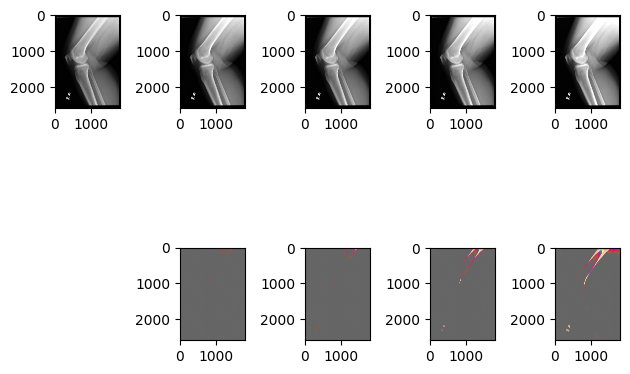

In [59]:
plt.subplot(251), plt.imshow(test_img_arr1, 'gray')
plt.subplot(252), plt.imshow(thresh_img0[1], 'gray')
plt.subplot(253), plt.imshow(thresh_img1[1], 'gray')
plt.subplot(254), plt.imshow(thresh_img2[1], 'gray')
plt.subplot(255), plt.imshow(thresh_img3[1], 'gray')

plt.subplot(257), plt.imshow(test_img_arr1-thresh_img0[1], 'Accent_r')
plt.subplot(258), plt.imshow(test_img_arr1-thresh_img1[1], 'Accent_r')

plt.subplot(259), plt.imshow(test_img_arr1-thresh_img2[1], 'Accent_r')
plt.subplot(2,5,10), plt.imshow(test_img_arr1-thresh_img3[1], 'Accent_r')


plt.tight_layout()

(<Axes: >, <matplotlib.image.AxesImage at 0x34869d090>)

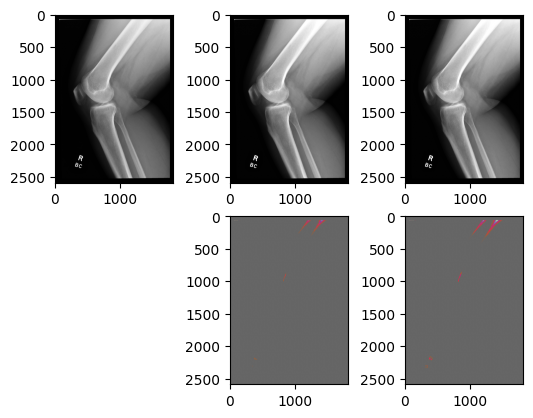

In [60]:
plt.subplot(231), plt.imshow(test_img_arr1, 'gray')
plt.subplot(232), plt.imshow(thresh_img0[1], 'gray')
plt.subplot(233), plt.imshow(thresh_img1[1], 'gray')
plt.subplot(235), plt.imshow(test_img_arr1-thresh_img0[1], 'Accent_r')
plt.subplot(236), plt.imshow(test_img_arr1-thresh_img1[1], 'Accent_r')

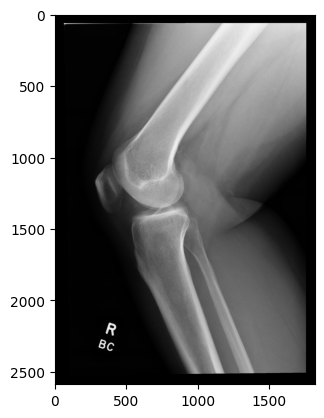

In [61]:
plt.imshow(test_img_arr1,cmap='gray')

### Deterministic image processing for removal of burned in information

Current x-ray images in this dataset and other datasets contained burned in information that is used to orient the x-ray image anatomically. While I could ignore these and just focus on segmentation, I'm not sure what additional information could be provided to any segmentation model as a result and so I would prefer to automatically remove it in a determinisitc and repeatable way.

I think there are two possible main routes:

1. Pure deterministic image processing
- image normalization
- possibly smoothing
- edge detection
- connected component analysis
- label dilation
- label masking 

2. OCR detection + deterministic image processing
- image normalization
- OCR label detection
- label dilation
- label masking


In [62]:
# image normalization
# Inew = (I - I.min) * (newmax - newmin)/(I.max - I.min)  + newmin

img = test_img_arr1.copy()
h, w =img.shape

p1, p99 = np.percentile(img,[1,99])
img_clip = np.clip(img,p1,p99)
img_norm = (img_clip - img_clip.min()) / (img_clip.max() - img_clip.min())

img_uint8 = (img_norm * 255).astype(np.uint8)


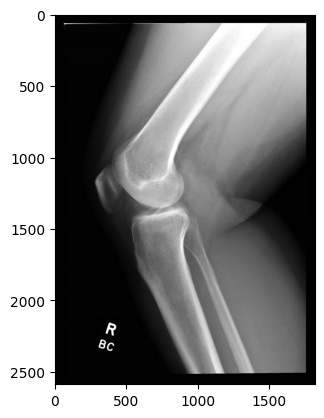

In [63]:
plt.imshow(img_uint8,cmap='gray')

In [64]:
# smoothing test
img_blur_arr = []

for m in range(1,7):
    img_blur = cv.blur(img,(5*m,5*m))
    img_blur_arr.append(img_blur)

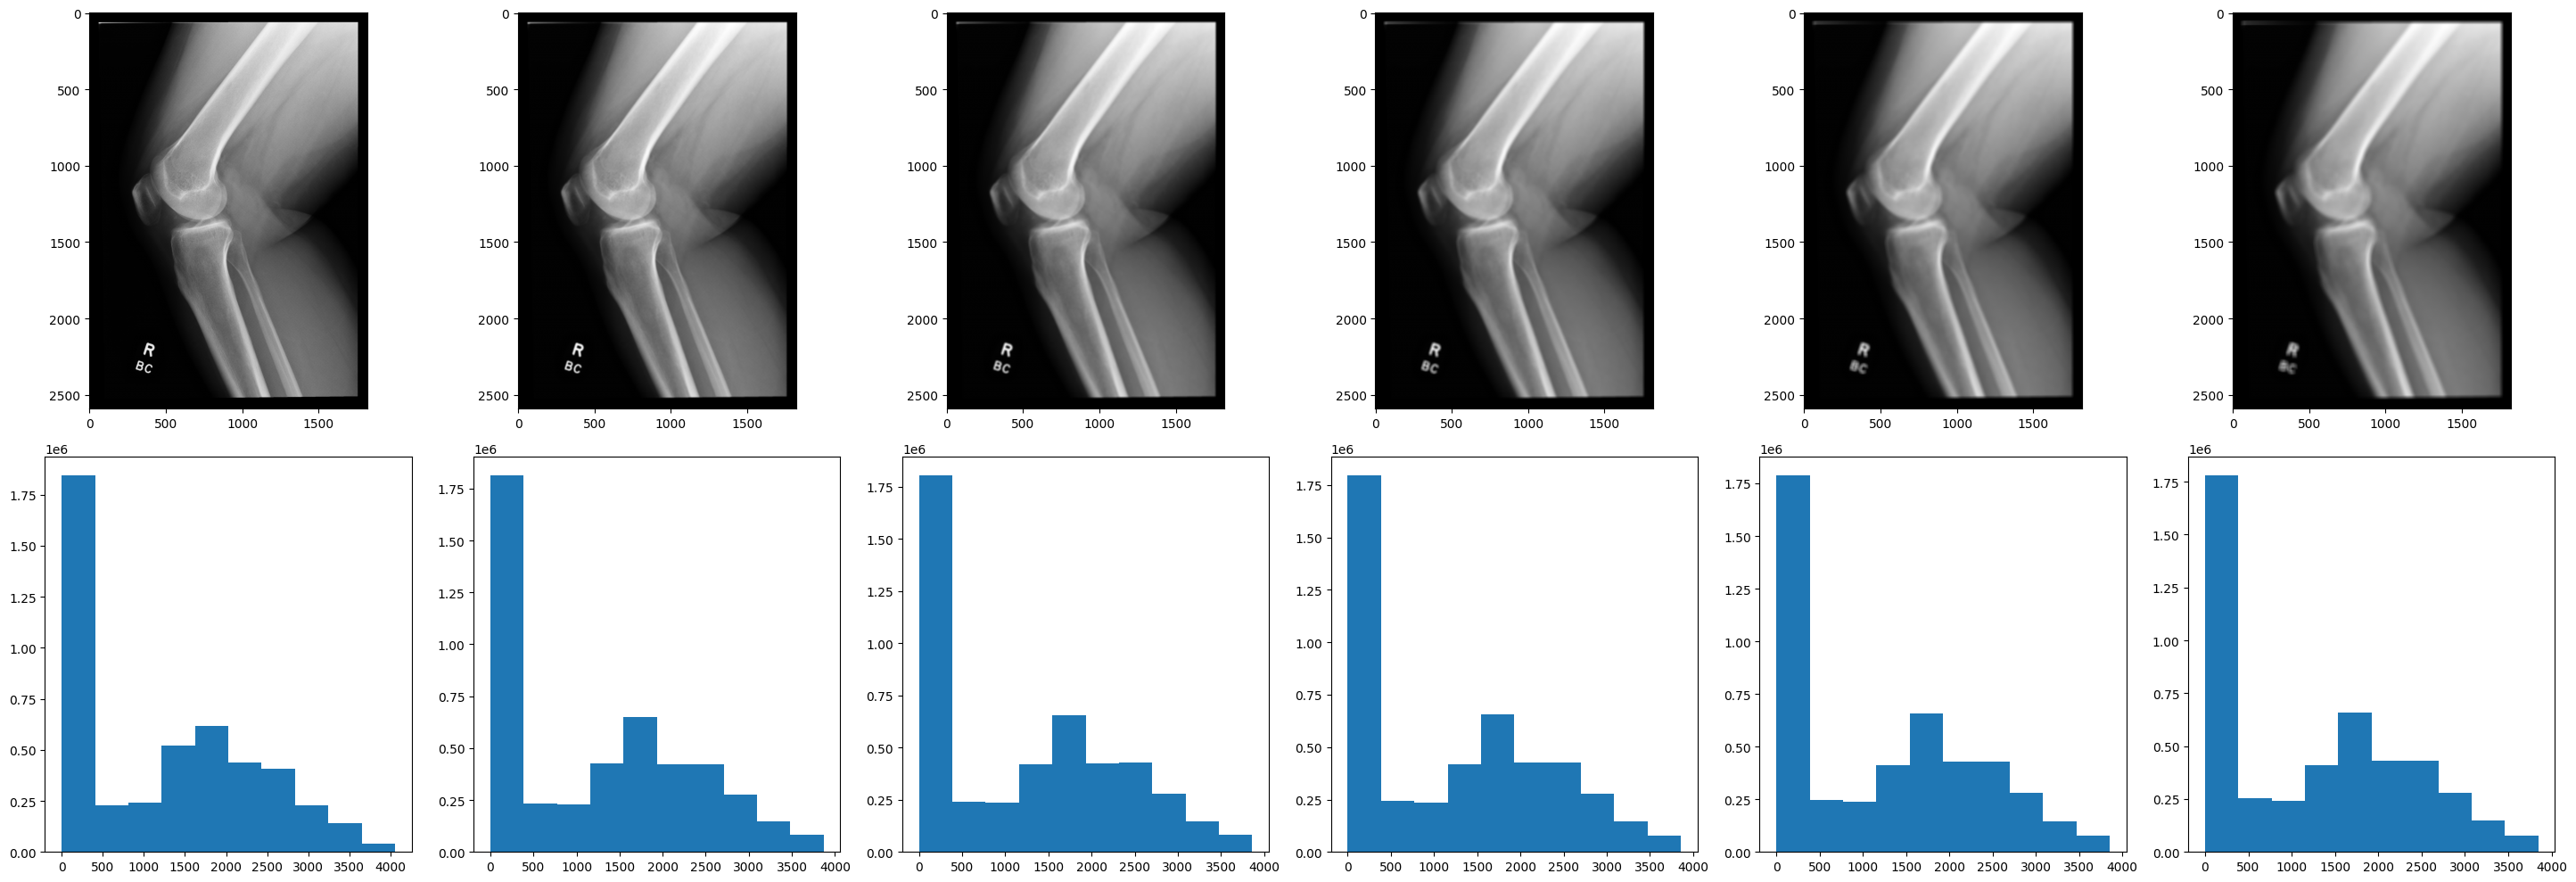

In [65]:
fig, ax = plt.subplots(2,6, figsize=(29,10))

ax[0][0].imshow(img,cmap='gray')

ax[1][0].hist(img.ravel())

for m in range(1,6):
    ax[0][m].imshow(img_blur_arr[m],cmap='gray')

    ax[1][m].hist(img_blur_arr[m].ravel())

plt.tight_layout()




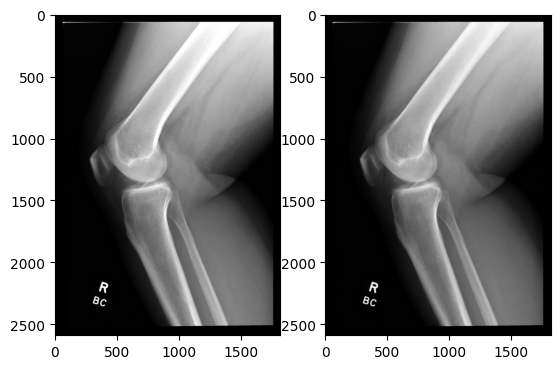

In [66]:
# smoothing gaussian test

img_gaus = cv.GaussianBlur(img,(5,5),0)

plt.subplot(121); plt.imshow(img_uint8,cmap='gray')
plt.subplot(122); plt.imshow(img_gaus,cmap='gray')


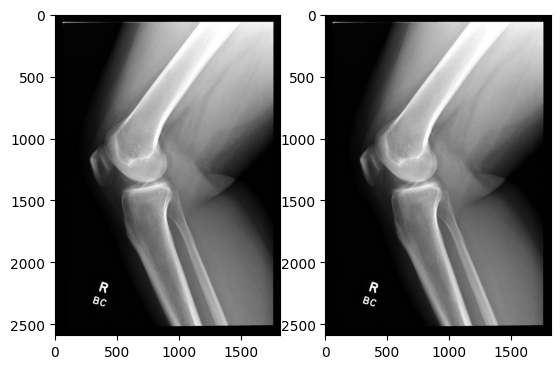

In [67]:
median = cv.medianBlur(img_uint8,5)

plt.subplot(121); plt.imshow(img_uint8,cmap='gray')
plt.subplot(122); plt.imshow(median,cmap='gray')

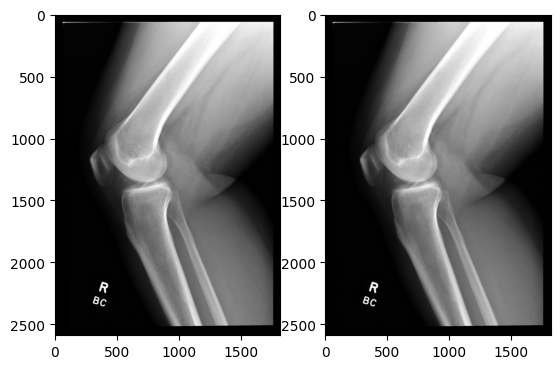

In [68]:
bilat_blur = cv.bilateralFilter(img_uint8,9,75,75)

plt.subplot(121); plt.imshow(img_uint8,cmap='gray')
plt.subplot(122); plt.imshow(bilat_blur,cmap='gray')

(array([ 957879., 1101601.,  376220.,  325554.,  338291.,  319529.,
         330810.,  315026.,  326134.,  320936.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

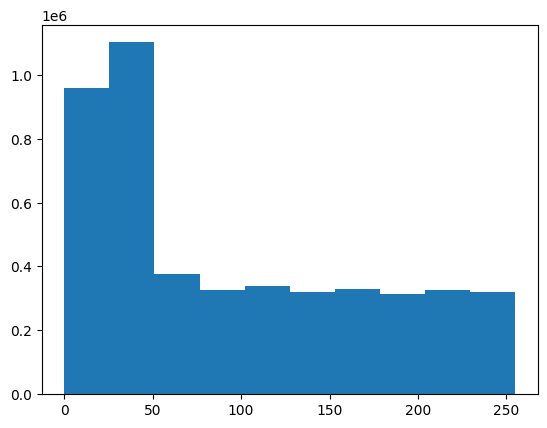

In [69]:
plt.hist(img_blur_arr[0].astype(np.uint8).ravel())

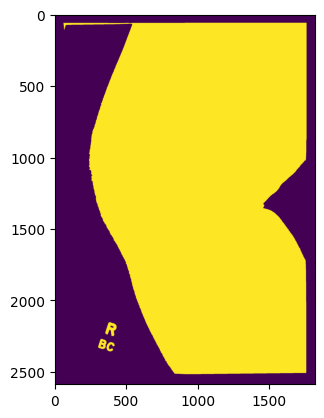

In [70]:
thresh_img = cv.threshold(img_blur_arr[0], 127, 255, cv.THRESH_BINARY)[1]

plt.imshow(thresh_img)

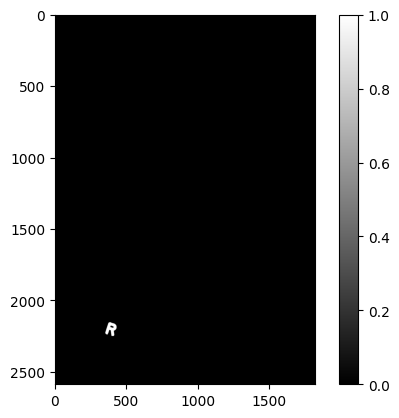

In [71]:
num_labels, labels, stats, _ = cv.connectedComponentsWithStats(thresh_img.astype(np.uint8), connectivity=8)
x, y, width, height, area = stats[0]
shw = plt.imshow(labels==2,cmap='gray')
plt.colorbar(shw)

In [335]:
edge_avg = cv.Canny(img_blur_arr[0].astype(np.uint8), 50, 150)

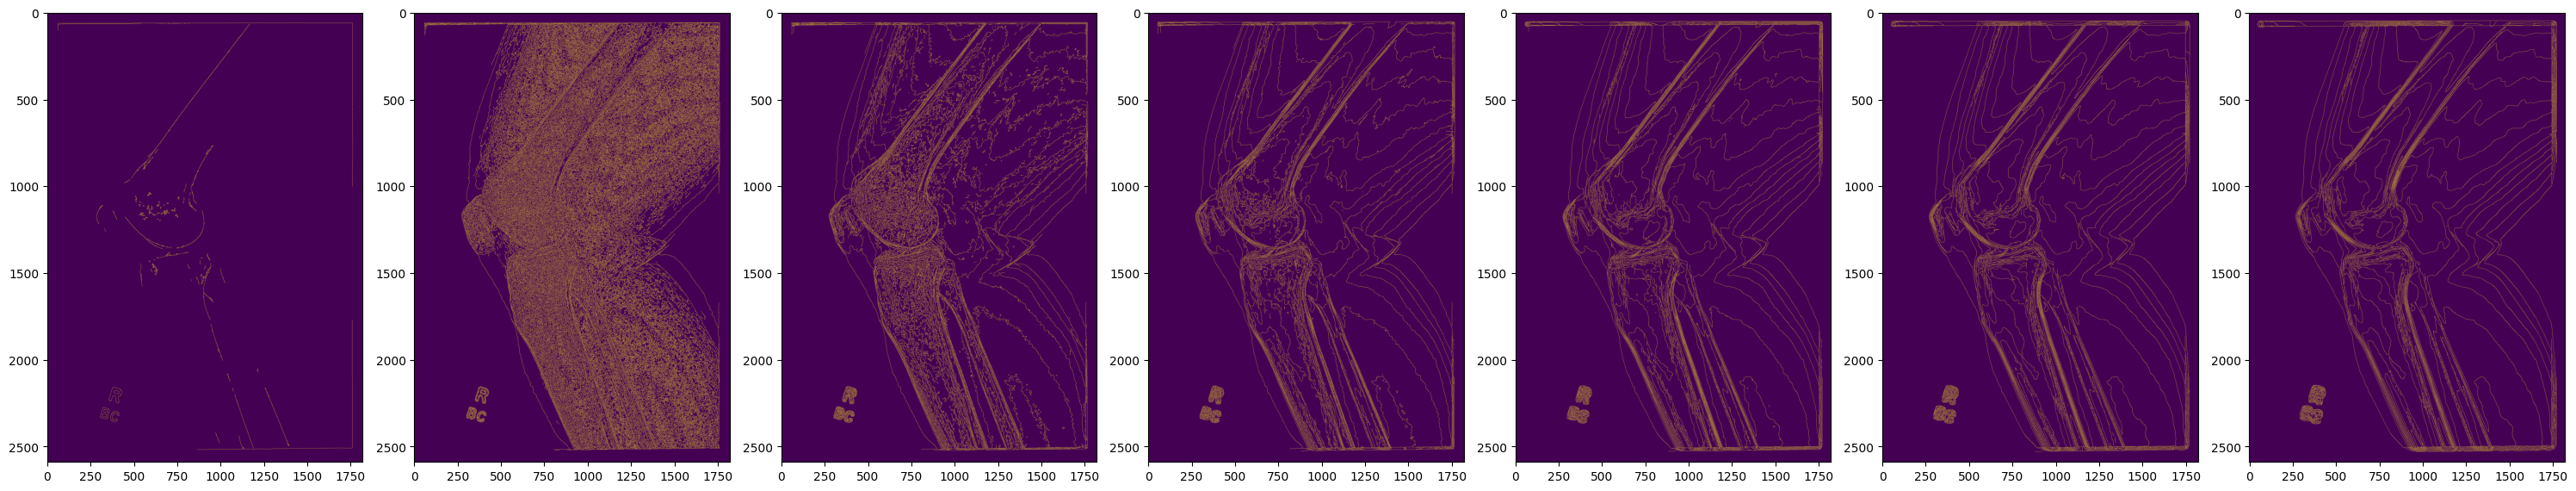

In [336]:
# trye edge detection with different types of filters
edges = cv.Canny(img_uint8,50,150)
edge_avg =[ cv.Canny(im.astype(np.uint8), 50, 150) for im in img_blur_arr ]


fig, ax = plt.subplots(1,len(edge_avg)+1,figsize=(30,10))
ax[0].imshow(edges)
for idx, edge_im in enumerate(edge_avg): 
    ax[idx+1].imshow(edge_im)
    
plt.tight_layout()

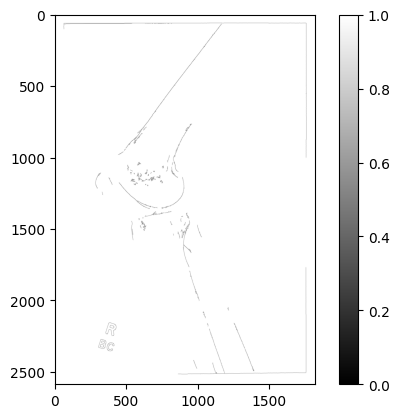

In [337]:
num_labels, labels, stats, _ = cv.connectedComponentsWithStats(edges, connectivity=8)
x, y, width, height, area = stats[0]
shw = plt.imshow(labels==0,cmap='gray')
plt.colorbar(shw)

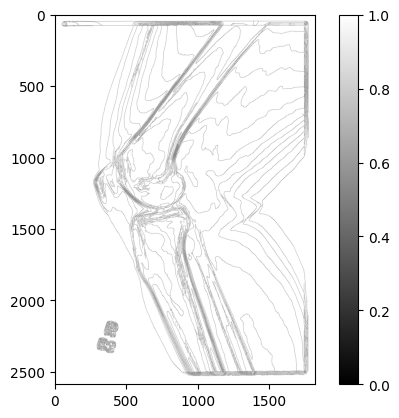

In [338]:
num_labels, labels, stats, _ = cv.connectedComponentsWithStats(edge_avg[-1], connectivity=4)
x, y, width, height, area = stats[0]
shw = plt.imshow(labels==0,cmap='gray')
plt.colorbar(shw)

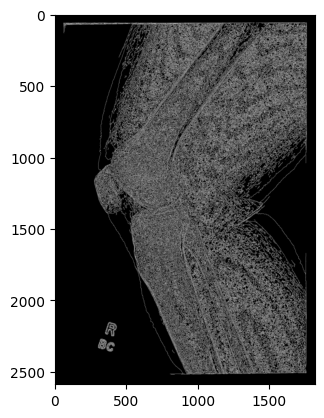

In [339]:
plt.imshow(cv.blur(edge_avg[0],(5,5)),cmap='gray')

In [340]:
max_area_ratio=0.01
border_ratio=0.12

for i in range(1, num_labels):
        x, y, width, height, area = stats[i]

        # Skip very large regions (likely anatomy)
        if area > max_area_ratio * (h * w):
            continue

        # Check if near border
        if (x < border_ratio*w or 
            x+width > (1-border_ratio)*w or 
            y < border_ratio*h or 
            y+height > (1-border_ratio)*h):

            text_mask[labels == i] = 255

In [341]:
kernel = np.ones((3,3), np.uint8)
text_mask = cv.dilate(text_mask, kernel, iterations=1)

# --- Inpaint in 8-bit domain ---
cleaned_uint8 = cv.inpaint(img_uint8, text_mask, 3, cv.INPAINT_TELEA)

# --- Transfer correction back to float domain ---
cleaned_float = img.copy()
cleaned_float[text_mask > 0] = np.median(img)

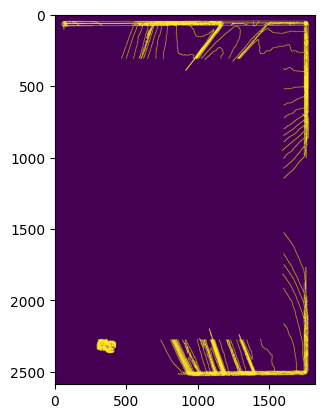

In [342]:
plt.imshow(text_mask)

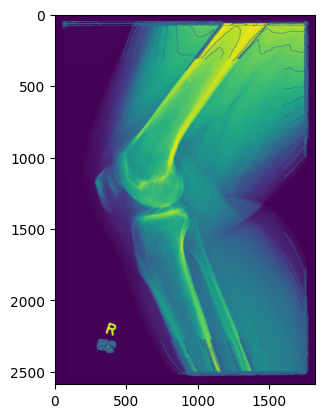

In [343]:
plt.imshow(cleaned_float)

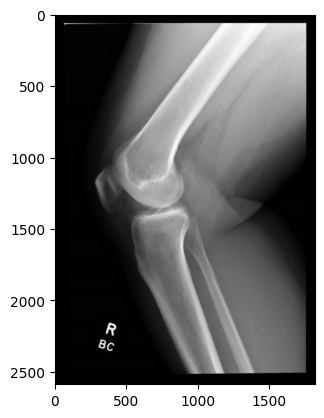

In [76]:
plt.imshow(img_blur_arr[0],'gray')

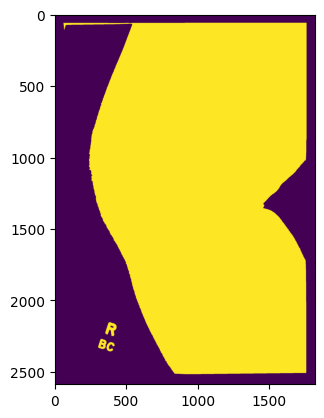

In [77]:
thresh_img = cv.threshold(img_blur_arr[0], 127, 255, cv.THRESH_BINARY)[1]

plt.imshow(thresh_img)

In [78]:
num_labels, labels, stats, _ = cv.connectedComponentsWithStats(thresh_img.astype(np.uint8), connectivity=8)
x, y, width, height, area = stats[0]


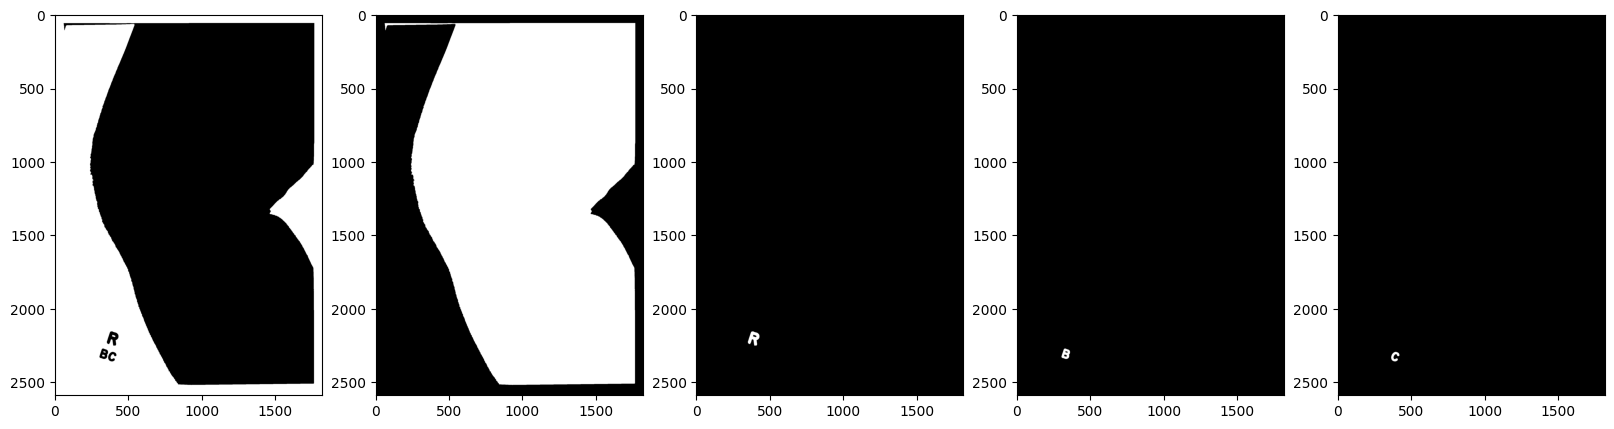

In [79]:
fig, ax = plt.subplots(1,num_labels, figsize=(20,10))

for i in range(num_labels):
    ax[i].imshow(labels==i,cmap='gray')


In [80]:
max_area_ratio =0.01
text_mask = np.zeros_like(img_uint8)

for i in range(1, num_labels):
        x, y, width, height, area = stats[i]

        # Skip very large regions (likely anatomy)
        if area > max_area_ratio * (h * w):
            continue
        else:
            text_mask[labels == i] = 255

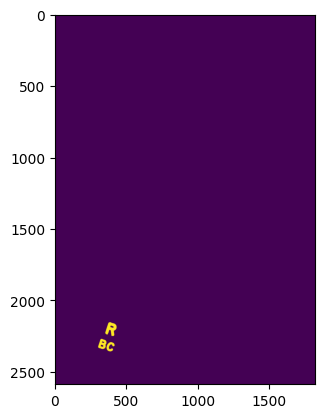

In [81]:
plt.imshow(text_mask)

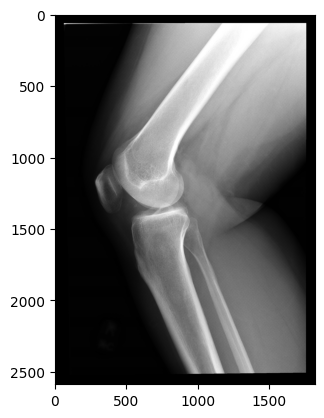

In [84]:
kernel = np.ones((3,3), np.uint8)
text_mask = cv.dilate(text_mask, kernel, iterations=3)

# --- Inpaint in 8-bit domain ---
cleaned_uint8 = cv.inpaint(img_uint8, text_mask, 2, cv.INPAINT_TELEA)

plt.imshow(cleaned_uint8,cmap='gray')

In [ ]:
mask_bool = text_mask > 0

cleaned_float = test_img_arr1.copy()
cleaned_float[mask_bool] = 0

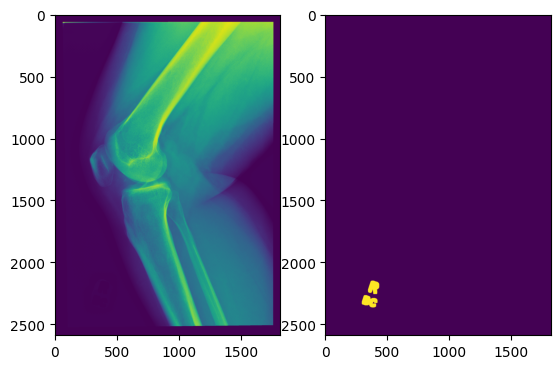

In [88]:
plt.subplot(121); shw1 = plt.imshow(cleaned_float); plt.Colormap(shw1)
plt.subplot(122); shw2 = plt.imshow(text_mask); plt.Colormap(shw2)

In [ ]:
def burned_text_removal_test(float_img: np.float32,
                        max_area_ratio =0.01,
   
                        dilation_iter=1
                        ):
    

    # image normalization
    # Inew = (I - I.min) * (newmax - newmin)/(I.max - I.min)  + newmin

    img = float_img.copy()
    h, w =img.shape

    p1, p99 = np.percentile(img,[1,99])
    img_clip = np.clip(img,p1,p99)
    img_norm = (img_clip - img_clip.min()) / (img_clip.max() - img_clip.min())

    img_uint8 = (img_norm * 255).astype(np.uint8)

    #image smoothing
    img_blur = cv.blur(img_uint8,(5,5))

    #thresholding
    #thresh_img = cv.threshold(img_blur, 127, 255, cv.THRESH_BINARY)[1]
    thresh_img = cv.adaptiveThreshold(img_blur,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)

    #connected component analysis
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(thresh_img.astype(np.uint8), connectivity=8)

    
    text_mask = np.zeros_like(img_uint8)

    for i in range(1, num_labels):
            x , y , width , height , area = stats[i]

            # Skip very large regions (likely anatomy)
            if area > max_area_ratio * (h * w):
                continue
            else:
                text_mask[labels == i] = 255

    #dilate mask
    kernel = np.ones((3,3), np.uint8)
    text_mask = cv.dilate(text_mask, kernel, iterations=dilation_iter)
    
    #masking
    mask_bool = (text_mask > 0).astype(np.uint8)

    cleaned_float = img.copy()

    cleaned_float = cv.inpaint(
        cleaned_float,
        mask_bool,
        5,
        cv.INPAINT_TELEA
        )

    return img_uint8, img_blur, thresh_img, labels, text_mask, cleaned_float

    

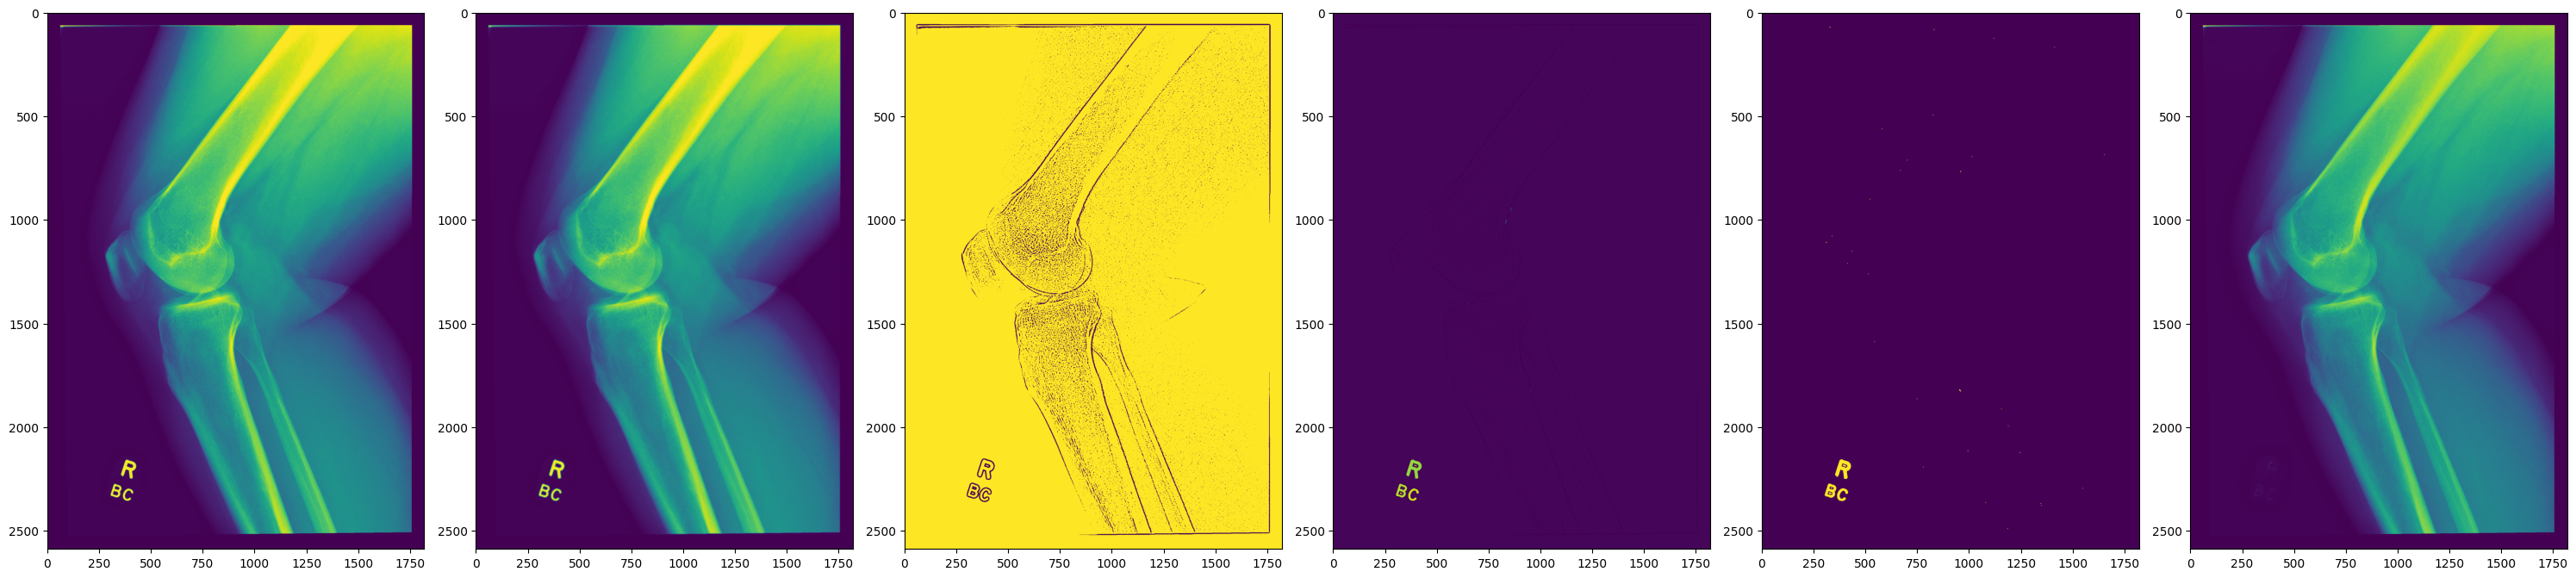

In [ ]:
test_out = burned_text_removal_test(test_img_arr1,border_ratio=0.3)
fig, ax = plt.subplots(1, len(test_out),figsize=[30,10])
for i in range(len(test_out)):
    ax[i].imshow(test_out[i])

plt.tight_layout()

In [141]:
lateral_view_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,inverted,arthroplasty,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,0,0,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,0,0,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...
2,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.25097243441976964330...,1775.0,1059.0,R,L,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
3,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.73980548070501957600...,1771.0,1058.0,L,L,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
4,10003180,1.2.845.113979.3.64.1.55016411.20170539.1,1.2.846.113564.1632467445.20170530081259855397,1.2.826.0.1.3680043.8.498.12678074990125916447...,2517.0,1985.0,R,L,0.0,1.0,0,R,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2017-11-09,67,10003180/1.2.845.113979.3.64.1.55016411.201705...


In [186]:
def get_test_img_full(index):
    img_path = os.path.join(mrkr_data_path,
                            'images',
                            lateral_view_df.iloc[index]['dicom_path'])
    
    return dcmread(img_path)

def get_test_img(index):
    img_path = os.path.join(mrkr_data_path,
                            'images',
                            lateral_view_df.iloc[index]['dicom_path'])
    
    return dcmread(img_path).pixel_array

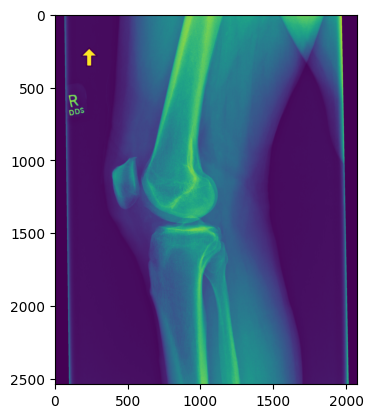

In [153]:
test2 = get_test_img(0)
plt.imshow(test2)

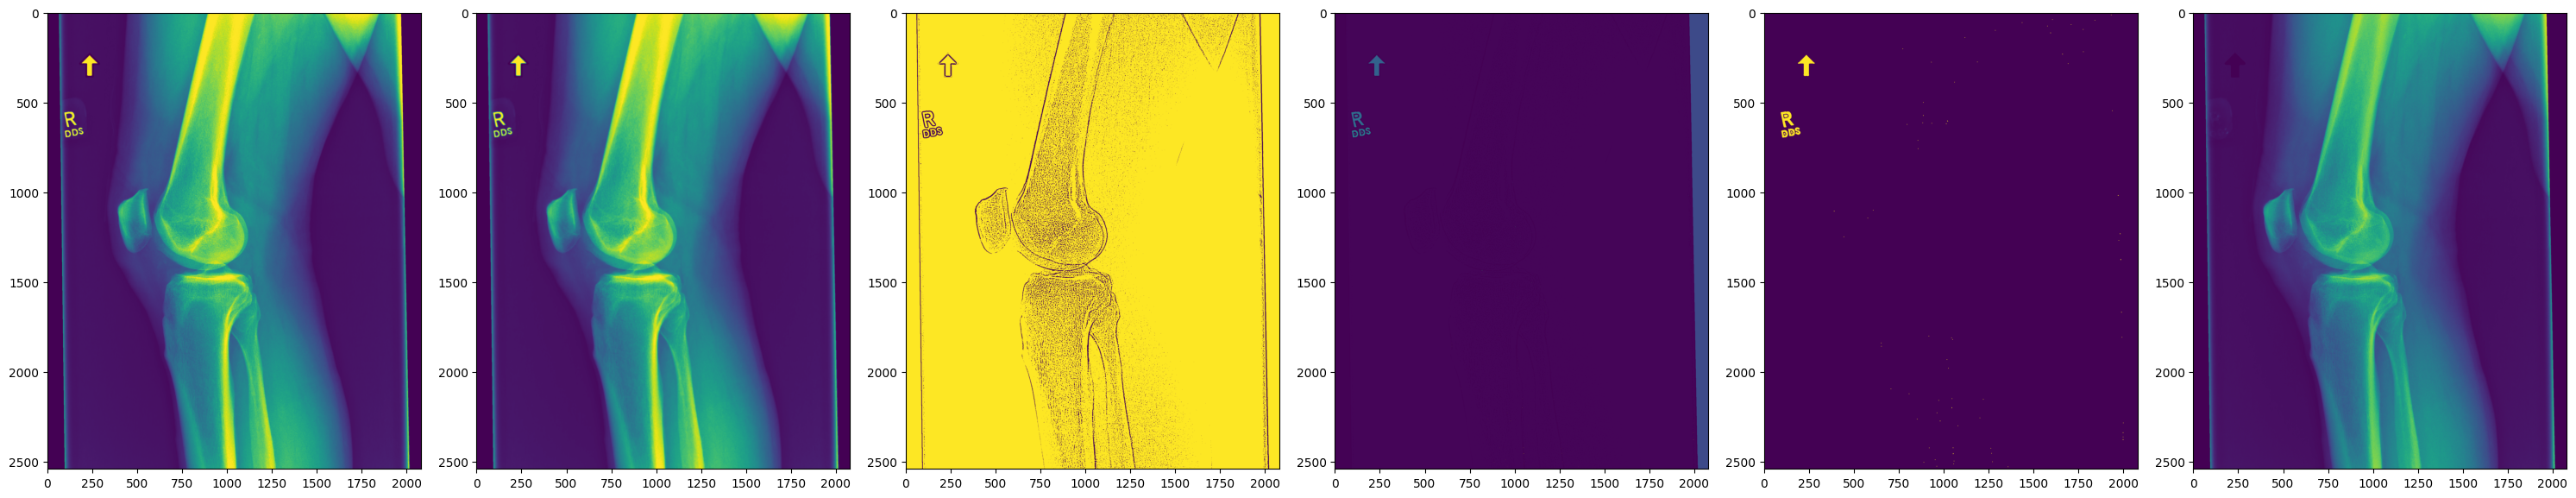

In [ ]:
test_out2 = burned_text_removal_test(test2)
fig, ax = plt.subplots(1, len(test_out2),figsize=[30,10])
for i in range(len(test_out2)):
    ax[i].imshow(test_out2[i])

plt.tight_layout()

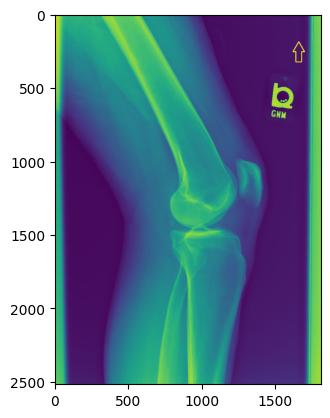

In [172]:
test45 = get_test_img(45)
plt.imshow(test45)

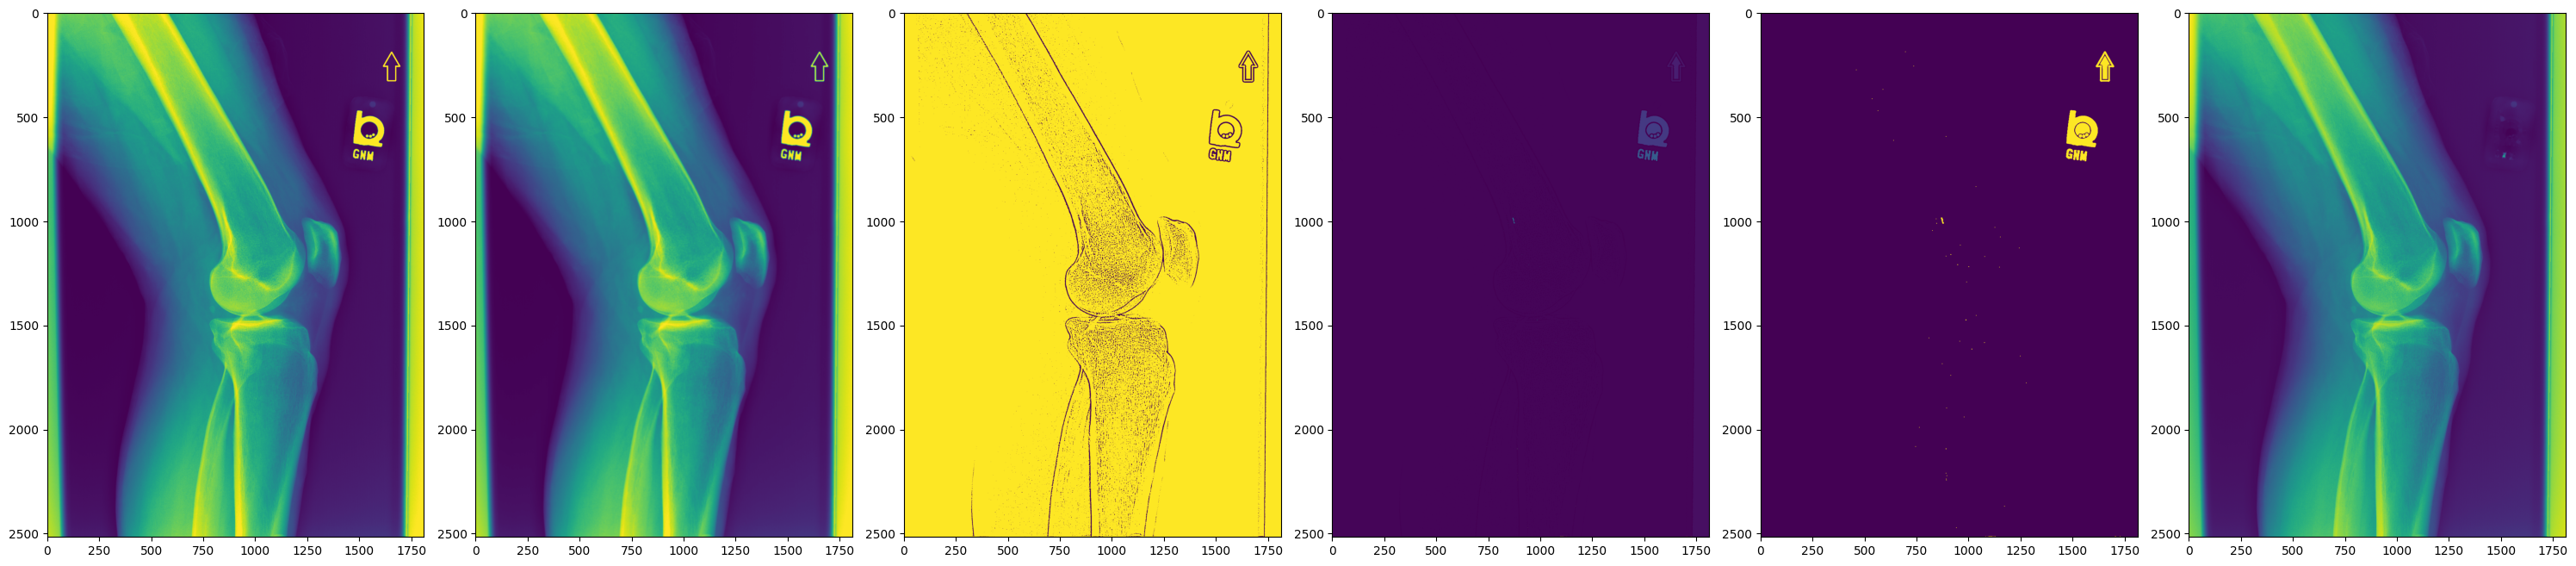

In [ ]:
test_out45 = burned_text_removal_test(test45)
fig, ax = plt.subplots(1, len(test_out45),figsize=[30,10])
for i in range(len(test_out45)):
    ax[i].imshow(test_out45[i])

plt.tight_layout()

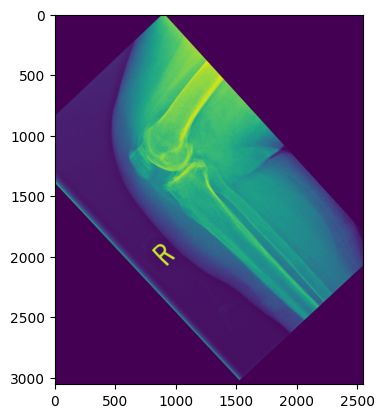

In [179]:
test100 = get_test_img(100)
plt.imshow(test100)

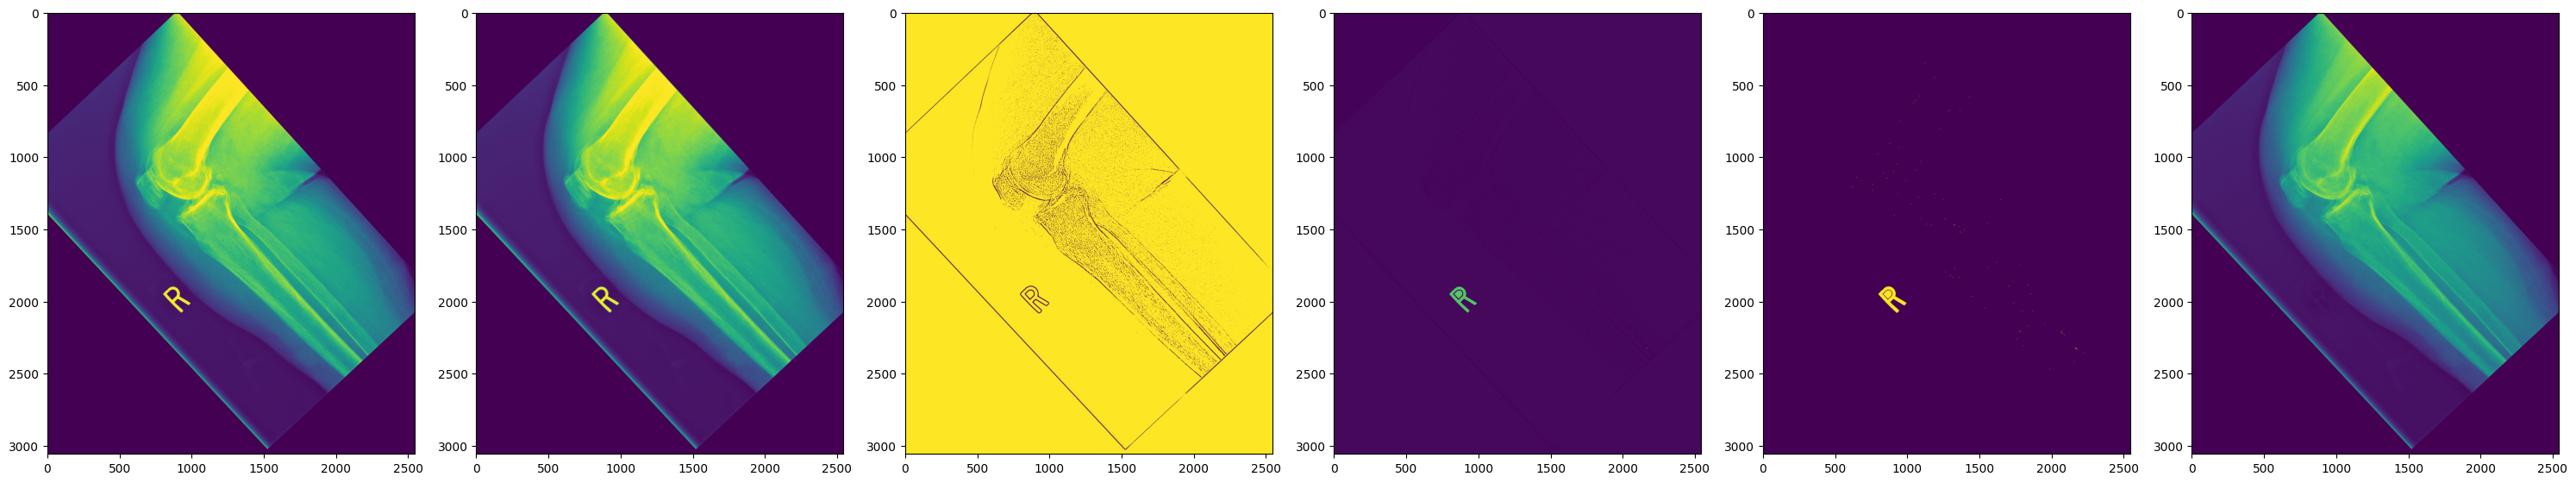

In [ ]:
test_out100 = burned_text_removal_test(test100)
fig, ax = plt.subplots(1, len(test_out100),figsize=[30,10])
for i in range(len(test_out100)):
    ax[i].imshow(test_out100[i])

plt.tight_layout()

In [ ]:
def normalize_img(img_float: np.float32) -> np.uint8:
    p1, p99 = np.percentile(img_float,[1,99])
    img_clip = np.clip(img_float,p1,p99)

    # Inew = (I - I.min) * (newmax - newmin)/(I.max - I.min)  + newmin
    img_norm = (img_clip - img_clip.min()) / (img_clip.max() - img_clip.min())

    img_uint8 = (img_norm * 255).astype(np.uint8)

    return img_uint8, p1, p99


def burned_text_removal(float_img: np.float32,
                        max_area_ratio = 0.01,
                        dilation_iter = 1
                        ) -> np.float32:
    

    # image normalization
    

    img = float_img.copy()
    h, w =img.shape

    img_uint8, _ , _ = normalize_img(img)

    #image smoothing
    img_blur = cv.blur(img_uint8,(5,5))

    #thresholding
    thresh_img = cv.adaptiveThreshold(img_blur,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)

    #connected component analysis
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(thresh_img.astype(np.uint8), connectivity=8)

    
    text_mask = np.zeros_like(img_uint8)

    for i in range(1, num_labels):
            x , y , width , height , area = stats[i]

            # Skip very large regions (likely anatomy)
            if area > max_area_ratio * (h * w):
                continue
            else:
                text_mask[labels == i] = 255

    #dilate mask
    kernel = np.ones((3,3), np.uint8)
    text_mask = cv.dilate(text_mask, kernel, iterations=dilation_iter)
    
    #masking
    mask_bool = (text_mask > 0).astype(np.uint8)

    cleaned_float = img.copy()

    cleaned_float = cv.inpaint(
        cleaned_float,
        mask_bool,
        5,
        cv.INPAINT_TELEA
        )

    return cleaned_float

    

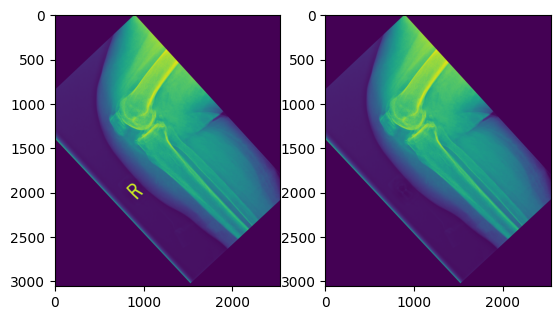

In [185]:
plt.subplot(121); plt.imshow(test100)
plt.subplot(122); plt.imshow(burned_text_removal(test100))

In [187]:
ds100 = get_test_img_full(100)

In [188]:
ds100

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 108
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: ''
(0002,0003) Media Storage SOP Instance UID      UI: ''
(0002,0010) Transfer Syntax UID                 UI: JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])
(0002,0012) Implementation Class UID            UI: ''
(0002,0013) Implementation Version Name         SH: 'EA4 30301.15165'
(0002,0016) Source Application Entity Title     AE: 'AE_ARCH2'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0016) SOP Class UID                       UI: Computed Radiography Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.826.0.1.3680043.8.498.825353832894992450755752483513041033

In [189]:
ds100.PhotometricInterpretation

'MONOCHROME2'

In [192]:
test100.shape

(3056, 2544)

In [1]:
print(lateral_view_df['img_height'].mean(),' +/- ',lateral_view_df['img_height'].std())
print(lateral_view_df['img_width'].mean(),' +/- ',lateral_view_df['img_width'].std())

NameError: name 'lateral_view_df' is not defined